In [1]:
from votekit import RankProfile, RankBallot
from votekit.elections import FastSTV

def my_map(bleh, lst):
    return (frozenset([item]) for item in lst)

test_profile = RankProfile( #L1 vs S2
    ballots=tuple(
        [
            RankBallot(ranking=tuple(my_map(frozenset, ["W1"])), weight=25000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W1", "S2", "W3"])), weight=15000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W1", "S2", "S3"])), weight=15000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W1", "L1"])), weight=5000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W1", "S3"])), weight=30000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W1", "W3"])), weight=60000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W2", "W3"])), weight=40000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W2", "S3"])), weight=40000),
            RankBallot(ranking=tuple(my_map(frozenset, ["W3"])), weight=50000),
            RankBallot(ranking=tuple(my_map(frozenset, ["S3"])), weight=70000),
            RankBallot(ranking=tuple(my_map(frozenset, ["L1", "W3"])), weight=5000),
            RankBallot(ranking=tuple(my_map(frozenset, ["L2", "W3"])), weight=4999),
            RankBallot(ranking=tuple(my_map(frozenset, ["S1", "W2"])), weight=20000),
            RankBallot(ranking=tuple(my_map(frozenset, ["S2", "W3"])), weight=10000),
            RankBallot(ranking=tuple(my_map(frozenset, ["S2", "W2"])), weight=10000),
        ]
    ),
    max_ranking_length=10,
)

elec = FastSTV(test_profile, 3)
elec.get_score_df()

,Round 0,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6,Round 7,Round 8
W1,150000.0,Elected,Elected,Elected,Elected,Elected,Elected,Elected,Elected
W2,80000.0,80000.0,80000.0,80000.0,100000.0,Elected,Elected,Elected,Elected
W3,50000.0,70000.0,74999.0,79999.0,79999.0,79999.0,94999.0,94999.0,Elected
S3,70000.0,80000.0,80000.0,80000.0,80000.0,80000.0,85000.0,0.0,0.0
S2,20000.0,30000.0,30000.0,30000.0,30000.0,30000.0,0.0,0.0,0.0
S1,20000.0,20000.0,20000.0,20000.0,0.0,0.0,0.0,0.0,0.0
L1,5000.0,6666.67,6666.67,0.0,0.0,0.0,0.0,0.0,0.0
L2,4999.0,4999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Quota,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0


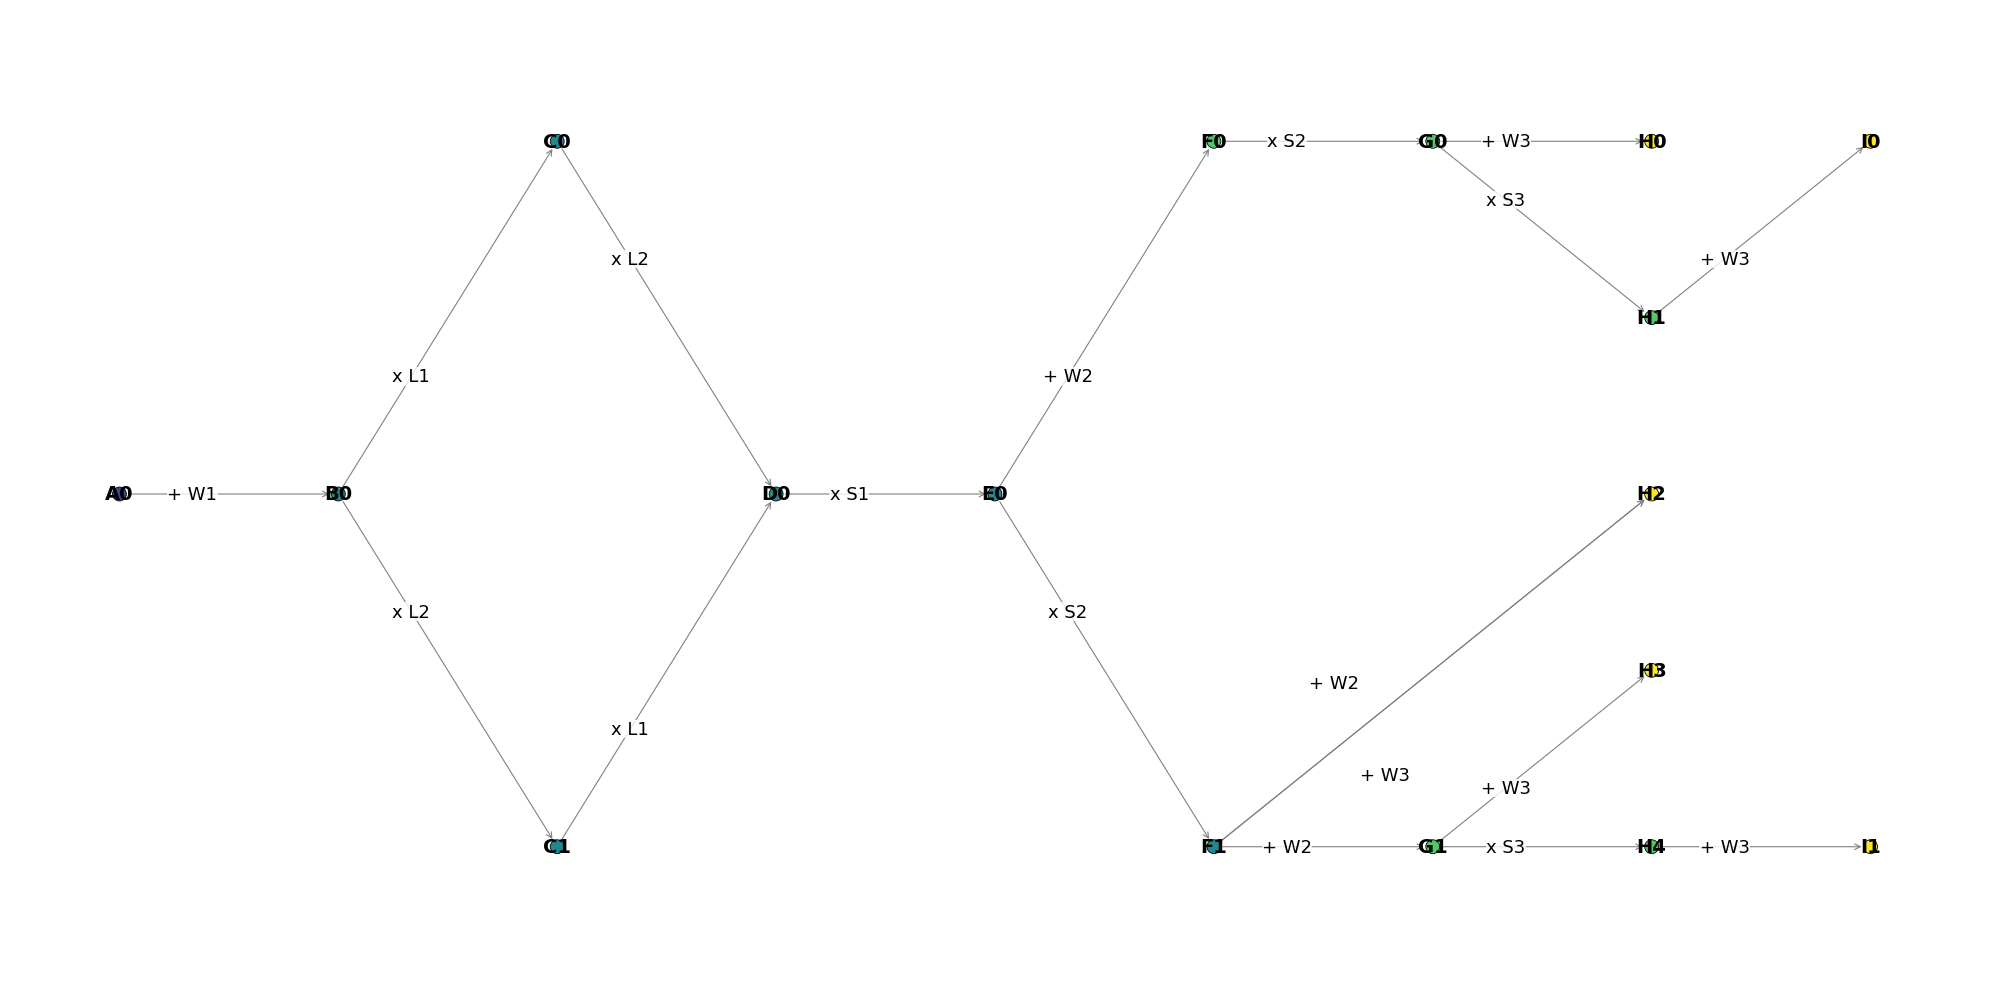

In [2]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor

constructor = WIGMGraphConstructor(test_profile, m=3, LAM = 9000, memory_lite = True,simultaneous=True)
constructor.build()

from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    #label_edges=None,
    label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)

In [3]:
from src.test_processes import VertexInterpreter

l1 = constructor.candidate_names.index("L1")
v1 = next(v for v in constructor.layers[1] if l1 in v.key.hopefuls)

interp1 = VertexInterpreter(constructor, v1)

base1 = interp1.base_point("S2", "L1")
base1

array([[ 20000.,   5000., 224999.],
       [ 30000.,   5000., 115000.]])

In [4]:
impacts = interp1.profile_theta_impacts("S2", "L1", radius=4000)
impacts

{(0, 1): 2.0,
 (0, 2): 1.0,
 (0, 3): 0.5270703322651374,
 (0, 4): 1.1790204541189717,
 (0, 5): 0.8639519609682867,
 (1, 0): -2.0,
 (1, 2): -1.0,
 (1, 3): -1.4729296677348627,
 (1, 4): -0.8209795458810283,
 (1, 5): -1.1360480390317131,
 (2, 0): -1.0,
 (2, 1): 1.0,
 (2, 3): -0.47292966773486256,
 (2, 4): 0.17902045411897172,
 (2, 5): -0.13604803903171325,
 (3, 0): -0.5864139613435917,
 (3, 1): 1.4135860386564083,
 (3, 2): 0.41358603865640836,
 (3, 4): 0.6301369863013699,
 (3, 5): 0.31506849315068497,
 (4, 0): -1.2621015348288076,
 (4, 1): 0.7378984651711924,
 (4, 2): -0.26210153482880755,
 (4, 3): -0.7012987012987013,
 (4, 5): -0.35064935064935066,
 (5, 0): -0.911452184179457,
 (5, 1): 1.088547815820543,
 (5, 2): 0.0885478158205431,
 (5, 3): -0.35064935064935066,
 (5, 4): 0.31506849315068497}

In [5]:
impacts = interp1.profile_theta_impacts("S2", "L1", radius=18000)
impacts

{(0, 1): 2.0,
 (0, 2): 1.0,
 (0, 3): 0.44288548752834467,
 (0, 4): 1.0702479338842976,
 (0, 5): 0.8263888888888904,
 (1, 0): -2.0,
 (1, 2): -1.0,
 (1, 3): -1.5571145124716552,
 (1, 4): -0.9297520661157025,
 (1, 5): -1.1736111111111096,
 (2, 0): -1.0,
 (2, 1): 1.0,
 (2, 3): -0.5571145124716553,
 (2, 4): 0.07024793388429754,
 (2, 5): -0.17361111111110963,
 (3, 0): -0.7174012855831038,
 (3, 1): 1.2825987144168962,
 (3, 2): 0.2825987144168962,
 (3, 4): 0.48484848484848486,
 (3, 5): 0.24242424242424243,
 (4, 0): -1.3799603174603174,
 (4, 1): 0.6200396825396826,
 (4, 2): -0.37996031746031744,
 (4, 3): -0.8095238095238095,
 (4, 5): -0.40476190476190477,
 (5, 0): -0.9751984126984127,
 (5, 1): 1.0248015873015872,
 (5, 2): 0.024801587301587304,
 (5, 3): -0.40476190476190477,
 (5, 4): 0.24242424242424243}

In [6]:
theta = interp1.theta(
    constructor.ballot_matrix[0],
    constructor.ballot_matrix[6],
    "S2",
    "L1",
)
print(theta)

result = interp1.optimize(base1, theta, radius=4000)
result

[[ 0.  0. -1.]
 [ 0.  0.  1.]]


0.0885478158205431

In [7]:
v2 = constructor.layers[6][0]

interp2 = VertexInterpreter(constructor, v2)

base2 = interp2.base_point("W3", "S3")
base2

array([[69999., 70000., 10000.],
       [75000., 45000., 30000.],
       [40000., 40000., 20000.],
       [    0.,     0.,     0.]])

In [8]:
impacts = interp2.profile_theta_impacts("W3", "S3", radius=18000)
impacts

{(0, 1): 2.0,
 (0, 2): 1.0,
 (0, 3): 0.4251700680272108,
 (0, 4): 0.9669421487603306,
 (0, 5): 0.7245179063360881,
 (0, 6): 0.7181844297615627,
 (0, 7): 0.5127900059488399,
 (0, 8): 0.7323022010707911,
 (1, 0): -2.0,
 (1, 2): -1.0,
 (1, 3): -1.5748299319727892,
 (1, 4): -1.0330578512396693,
 (1, 5): -1.275482093663912,
 (1, 6): -1.2818155702384373,
 (1, 7): -1.48720999405116,
 (1, 8): -1.2676977989292089,
 (2, 0): -1.0,
 (2, 1): 1.0,
 (2, 3): -0.5748299319727892,
 (2, 4): -0.03305785123966942,
 (2, 5): -0.27548209366391185,
 (2, 6): -0.2818155702384373,
 (2, 7): -0.48720999405116,
 (2, 8): -0.2676977989292088,
 (3, 0): -0.6887052341597796,
 (3, 1): 1.3112947658402203,
 (3, 2): 0.3112947658402204,
 (3, 4): 0.48484848484848486,
 (3, 5): 0.24242424242424243,
 (3, 6): 0.1848510964282294,
 (3, 7): -0.020543327384493326,
 (3, 8): 0.19896886773745787,
 (4, 0): -1.3622448979591837,
 (4, 1): 0.6377551020408163,
 (4, 2): -0.3622448979591837,
 (4, 3): -0.8095238095238095,
 (4, 5): -0.404761904761

In [9]:
import matplotlib.pyplot as plt

from src.test_processes import (
    CobraCompilerV2,
    ImplicitSampler,
    VertexInterpreter,
    plot_profiled_compiler,
)

# Shared implicit sampler
sampler = ImplicitSampler.from_profile(
    constructor.profile,
    noise_level=0.05,
    sample_size=50_000,
    with_replacement=True,
    seed=20260621,
)

In [10]:
l1 = constructor.candidate_names.index("L1")
v1 = next(v for v in constructor.layers[1] if l1 in v.key.hopefuls)

interp1 = VertexInterpreter(constructor, v1)

compiler1 = CobraCompilerV2(
    interp1,
    "S2",
    "L1",
    radius=4_000,
    profile=True,
    optimizer_kwargs={"maxiter": 300},
)

compiler1.run_sampler(sampler)
compiler1

CobraCompilerV2(label=B0: S2>L1, critical_margin=23333.333333333336, v=0.05833347916703126, radius=4000.0, lambda_value=1.9, M=22.69418865375212, num_updates=134, cached_thetas=5)

In [11]:
v2 = constructor.layers[6][0]

interp2 = VertexInterpreter(constructor, v2)

compiler2 = CobraCompilerV2(
    interp2,
    "W3",
    "S3",
    radius=50_000,
    profile=True,
    optimizer_kwargs={"maxiter": 300},
)

compiler2.run_sampler(sampler)
compiler2

CobraCompilerV2(label=G0: W3>S3, critical_margin=9999.0, v=0.024997562493906236, radius=50000.0, lambda_value=1.9, M=20.16032467166713, num_updates=149, cached_thetas=4)

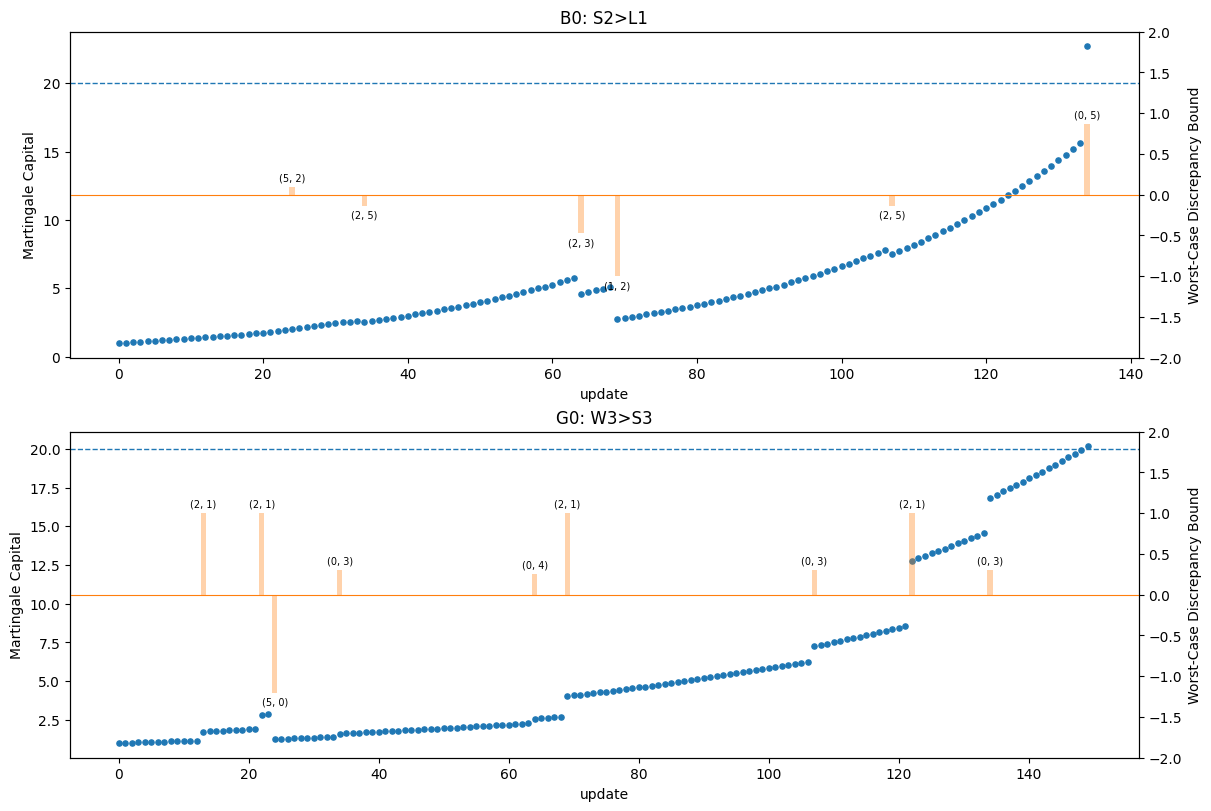

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

plot_profiled_compiler(compiler1, ax=axes[0])
plot_profiled_compiler(compiler2, ax=axes[1])

plt.show()

In [13]:
from src.test_processes import CobraQuotaCompilerV2, CriticalMarginType

D0_vertex = constructor.lookup_vertex("D0")
interpreter_A0 = VertexInterpreter(constructor, D0_vertex)

quota_compiler = CobraQuotaCompilerV2(
    interpreter_A0,
    "W2",
    margin_type=CriticalMarginType.CANDIDATE_BELOW_QUOTA,
    radius=50_000,
    profile=True,
    optimizer_kwargs={"maxiter": 300},
)
quota_compiler.run_sampler(sampler)

Vertex D0
  ref: VertexRef(layer=3, local_id=0)
  status: EXPANDED
  degree: 1
  color: 1
  path_multiplicity: 2
  tightest_margin: None
  elected candidates:
    (0, 0.3333333333333333)
  hopefuls:
    1: S2
    2: W3
    3: S3
    5: W2
    7: S1
  tallies:
    0: W1 -> 0.0
    1: S2 -> 30000.0
    2: W3 -> 79999.0
    3: S3 -> 80000.0
    4: L1 -> 0.0
    5: W2 -> 80000.0
    6: L2 -> 0.0
    7: S1 -> 20000.0


128

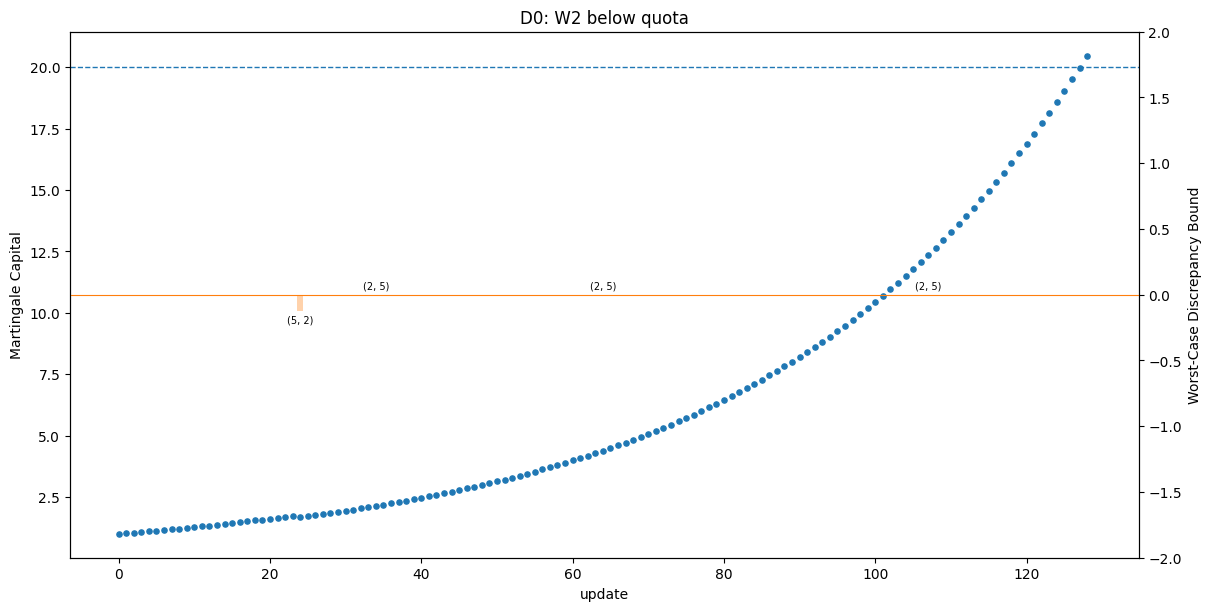

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plot_profiled_compiler(quota_compiler, ax=ax)
plt.show()

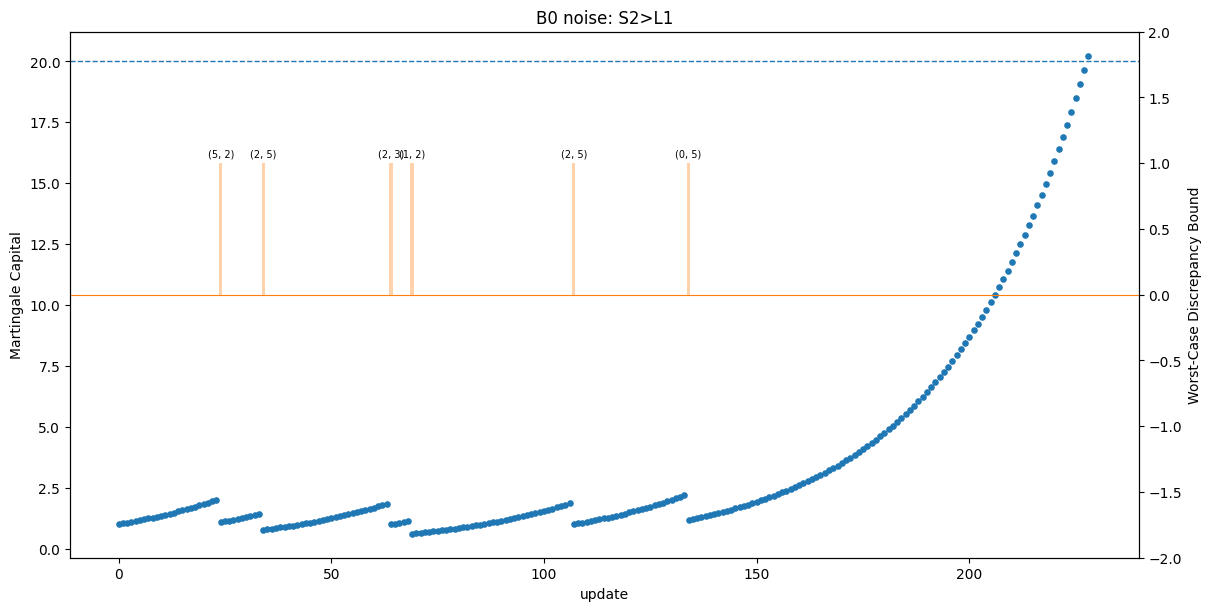

In [15]:
from src.test_processes import CobraNoiseFilterCompiler

noise_compiler = CobraNoiseFilterCompiler(
    interp1,
    "S2",
    "L1",
    radius=50_000,
    profile=True,
)
noise_compiler.run_sampler(sampler)
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plot_profiled_compiler(noise_compiler, ax=ax)
plt.show()

V2 audit diagnostic after 100 samples: 105 compilers remain below threshold (49/154 certified).
  F0-W1-N: M=0.872312, escape=ELECT 1:S2 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
  F0-E3-N: M=0.872312, escape=ELIMINATE 3:S3 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
  F0-W3-N: M=0.872312, escape=ELECT 3:S3 noise, margin=15000.0, kind=CobraQuotaNoiseFilterCompiler
  G0-E2-N: M=0.872312, escape=ELIMINATE 2:W3 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
  G0-W3-N: M=0.872312, escape=ELECT 3:S3 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
V2 audit diagnostic after 200 samples: 88 compilers remain below threshold (66/154 certified).
  G0-E2-N: M=0.760929, escape=ELIMINATE 2:W3 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
  G0-W3-N: M=0.760929, escape=ELECT 3:S3 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
  G1-E2-N: M=0.760929, escape=ELIMINATE 2:W3 noise, margin=15000.0, kind=CobraNoiseFilterCompiler
  G1-W3-N: M=0.760929, escape=ELECT 

[(70, 129, 'F0-W1-N', (6, 8), 1.0),
 (70, 135, 'F0-E3-N', (6, 8), 1.0),
 (70, 136, 'F0-W3', (7, 8), -0.23076923076923073),
 (70, 137, 'F0-W3-N', (7, 8), 1.0),
 (70, 146, 'G0-E2', (7, 8), -0.23076923076923073),
 (70, 147, 'G0-E2-N', (7, 8), 1.0),
 (70, 148, 'G0-W3', (7, 8), -0.23076923076923073),
 (70, 149, 'G0-W3-N', (7, 8), 1.0),
 (70, 150, 'G1-E2', (7, 8), -0.2857142857142857),
 (70, 151, 'G1-E2-N', (7, 8), 1.0)]

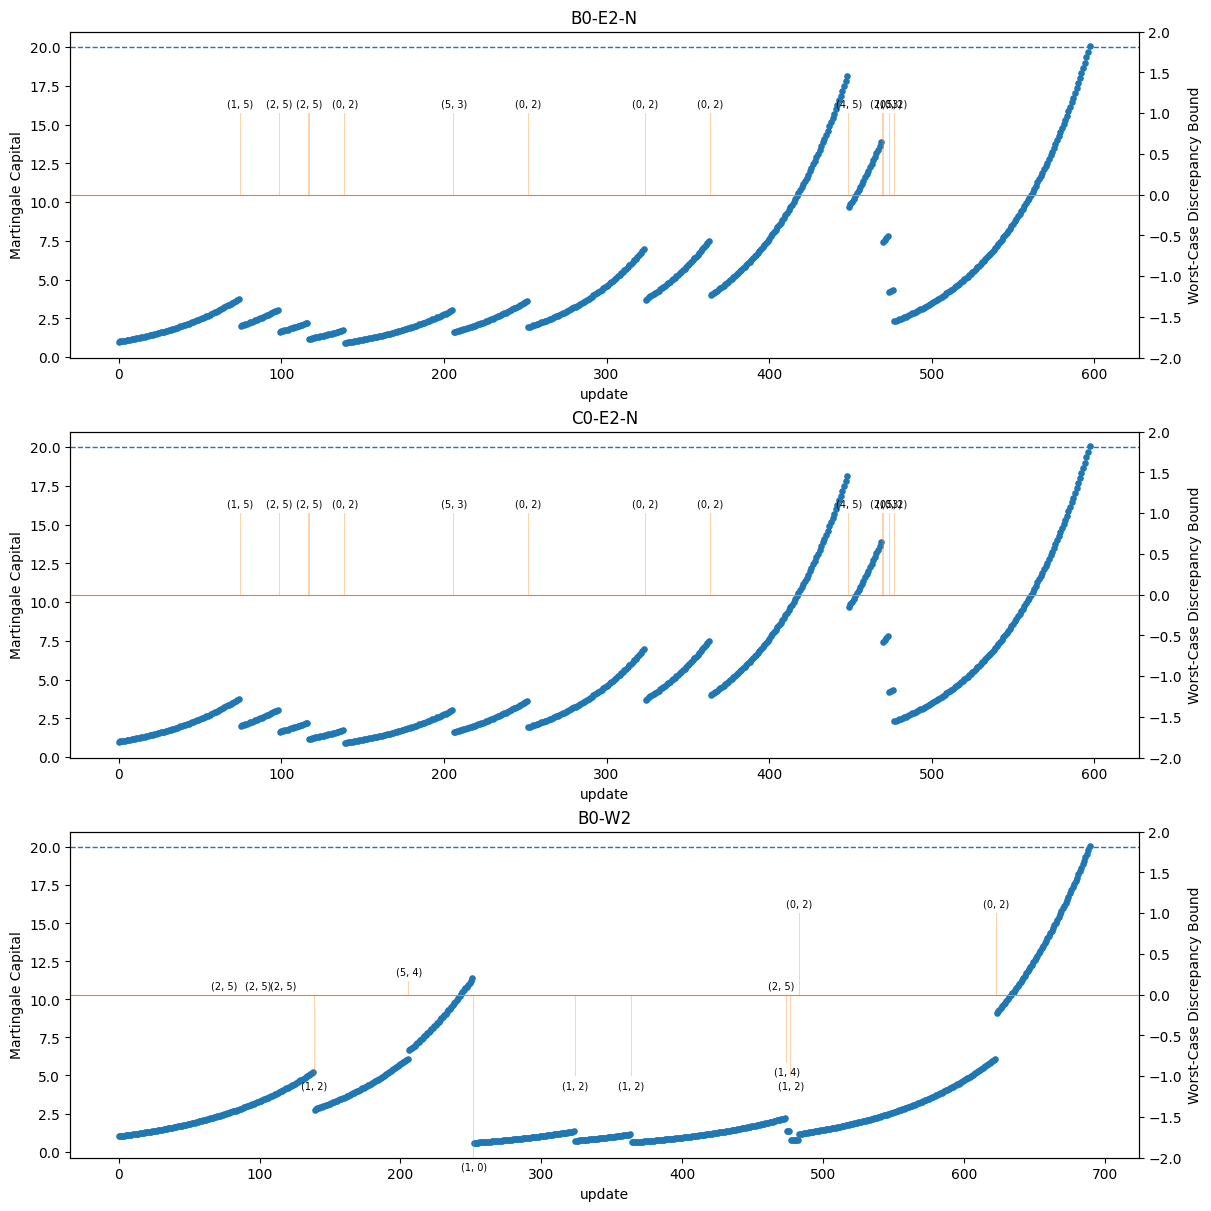

In [ ]:
from src.test_processes import GlobalAuditDriverV2

driver = GlobalAuditDriverV2(
    constructor,
    noise_level=0.02,
    r=30_000,
    sample_size=50_000,
    seed=2026062,
    profile=True,
    optimizer_kwargs={"maxiter": 300},
    print_diagnostics_every=100,
)

driver.run()

driver.discrepancies[:10]

Coherence check failed.
  distinct terminal winner sets: 2
  candidates shared by all winner sets: ['Candace Avalos', 'Loretta Smith']

  winner set: ['Jamie Dunphy', 'Candace Avalos', 'Loretta Smith']
    completion beyond shared core: ['Jamie Dunphy']
    terminal node count: 10
    terminal nodes: ['Q0', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']

  winner set: ['Candace Avalos', 'Terrence Hayes', 'Loretta Smith']
    completion beyond shared core: ['Terrence Hayes']
    terminal node count: 1
    terminal nodes: ['Q1']


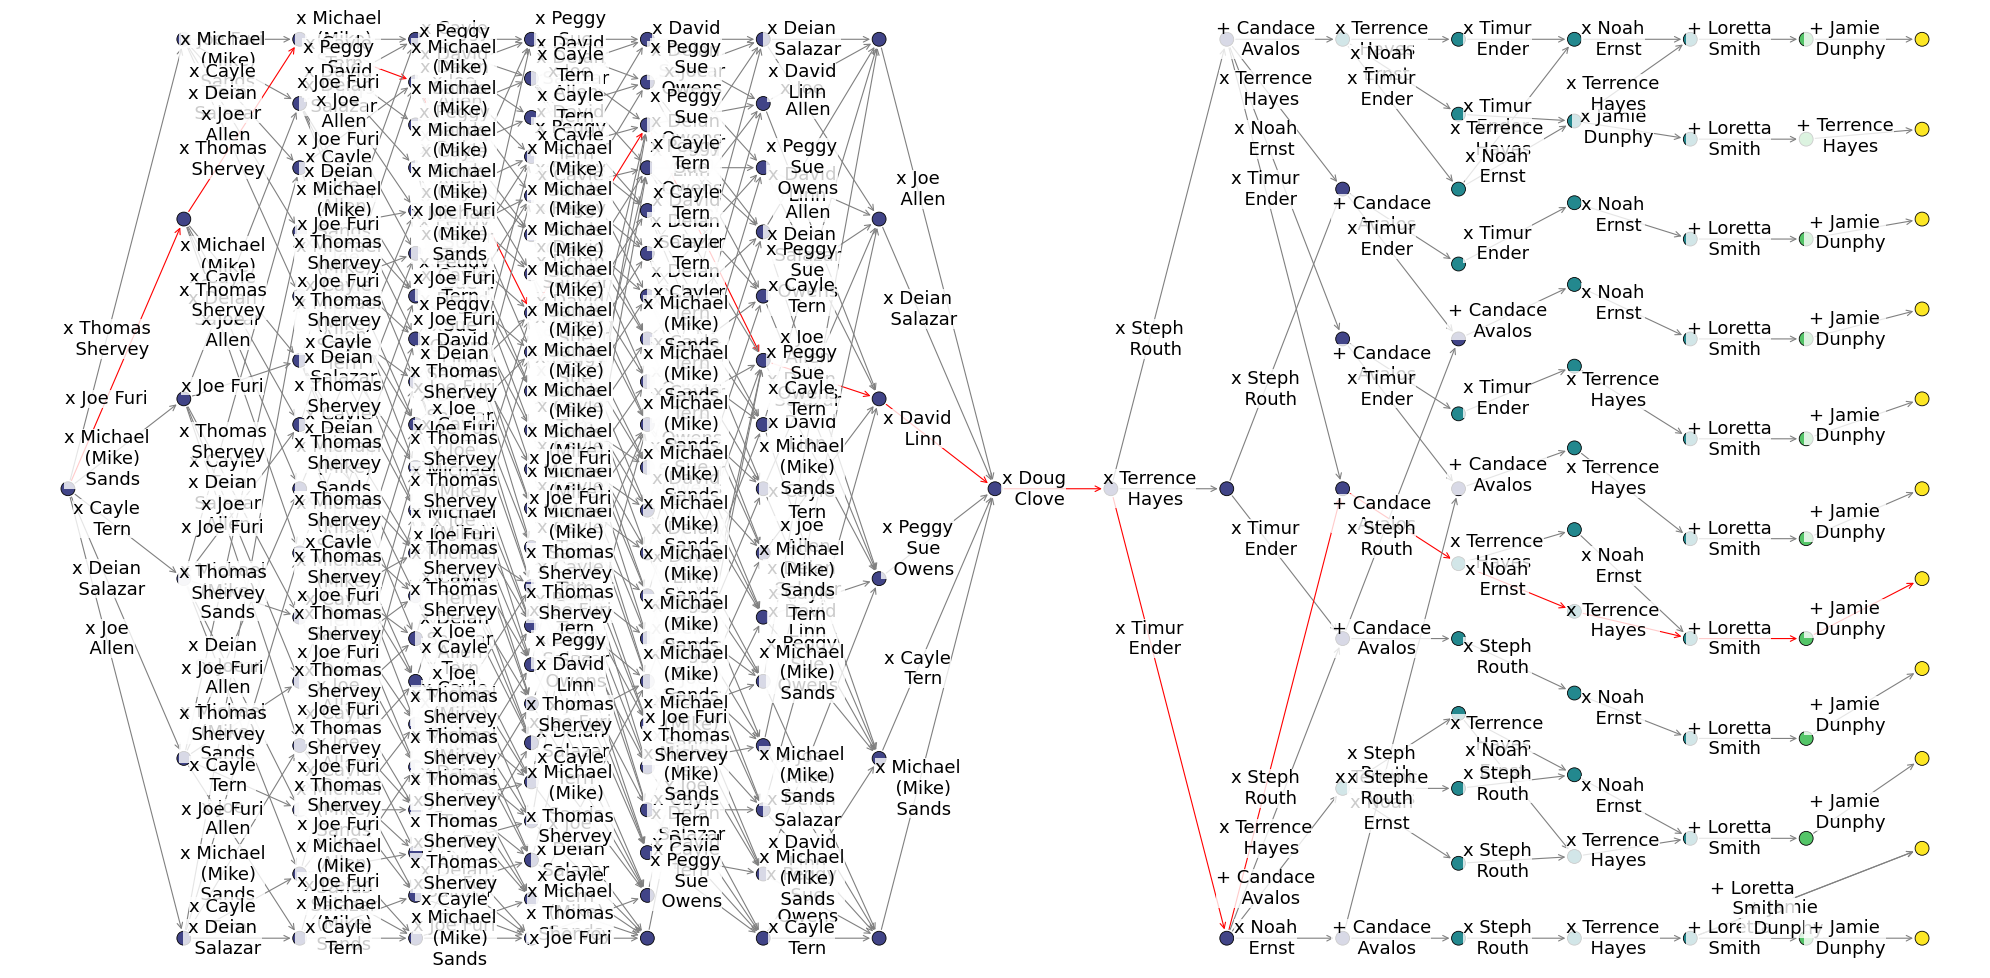

In [6]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor
from votekit.cvr_loaders import load_numpy

portland_D1 = load_numpy("/home/nardo/research/data/election_data/votekit/portland/portland_d1_2024.csv")[0]

constructor = WIGMGraphConstructor(portland_D1, m=3, LAM = 672, memory_lite = True,simultaneous=True)
constructor.build()
constructor.coherence_check()

from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    #label_edges=None,
    label_vertices=False,
    highlight_natural_path=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)

In [4]:
portland_D1.total_ballot_wt

42678.0

Initializing GlobalAuditDriverV2.
  graph: candidates=16, seats=3, LAM=670, seeded=False
  sample source: implicit sampler with 50000 rows and noise_level=0.02
Initializing escape-edge compilers.
  layer 0: visited 1 vertices, added 52 compilers
  layer 1: visited 6 vertices, added 300 compilers
  layer 2: visited 15 vertices, added 716 compilers
  layer 3: visited 22 vertices, added 988 compilers
  layer 4: visited 24 vertices, added 996 compilers
  layer 5: visited 22 vertices, added 844 compilers
  layer 6: visited 15 vertices, added 540 compilers
  layer 7: visited 6 vertices, added 204 compilers
  layer 8: visited 1 vertices, added 30 compilers
  layer 9: visited 1 vertices, added 22 compilers
  layer 10: visited 3 vertices, added 52 compilers
  layer 11: visited 7 vertices, added 102 compilers
  layer 12: visited 13 vertices, added 164 compilers
  layer 13: visited 12 vertices, added 120 compilers
Removed 290 duplicate V2 compilers.
Initialized 4840 V2 compilers across 148 vertex

[CobraNoiseFilterCompiler(label=M7-W11-N (Noah Ernst), critical_margin=1250.0, v=0.02928909508411828, radius=2500.0, lambda_value=1.3, M=20.192684511498918, num_updates=724, cached_thetas=0),
 CobraCompilerV2(label=N4-W2 (Jamie Dunphy), critical_margin=762.1468195270663, v=0.017858072532149265, radius=2500.0, lambda_value=1.3, M=20.081616890446227, num_updates=763, cached_thetas=5),
 CobraCompilerV2(label=N7-W2 (Jamie Dunphy), critical_margin=670.0908045033684, v=0.015701082630473977, radius=2500.0, lambda_value=1.3, M=20.091500249329524, num_updates=982, cached_thetas=8)]

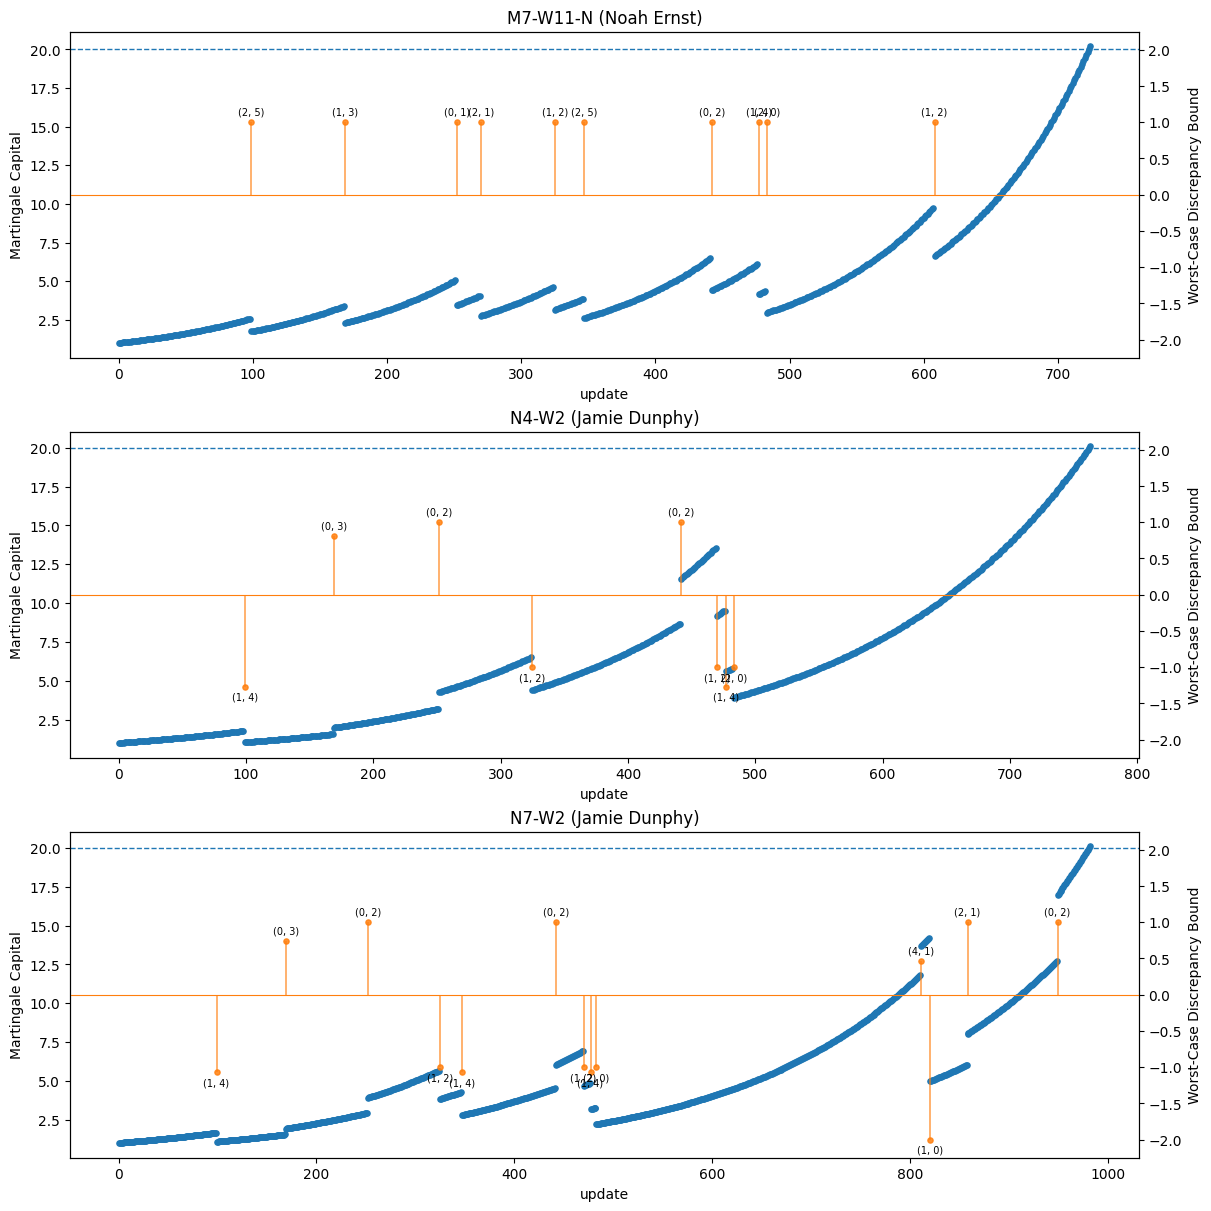

In [3]:
from src.test_processes import GlobalAuditDriverV2

driver = GlobalAuditDriverV2(
    constructor,
    noise_level=0.02,
    r=2500,
    sample_size=50_000,
    seed=2026063,
    profile=True,
    optimizer_kwargs={"maxiter": 300},
    print_diagnostics_every=100,
    lambda_value = 1.3
)

driver.run()
driver.plot_profile()

#driver.discrepancies[:10]